# Relational analysis - Chekpoint 3

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

The following analysis was developed based on a social network graph. The graph represents the interaction in Twitter of US congress' members, where each node represents a person that is part of the congress, and the edges (weighted) their connection (retweet, quote tweet, reply, or mention  of another member). In summary, this graph represents the spreading of opinion/ideas among the members of the US congress.

This network dataset was extracted from https://snap.stanford.edu/data/congress-twitter.html

# **Loading social network graph**

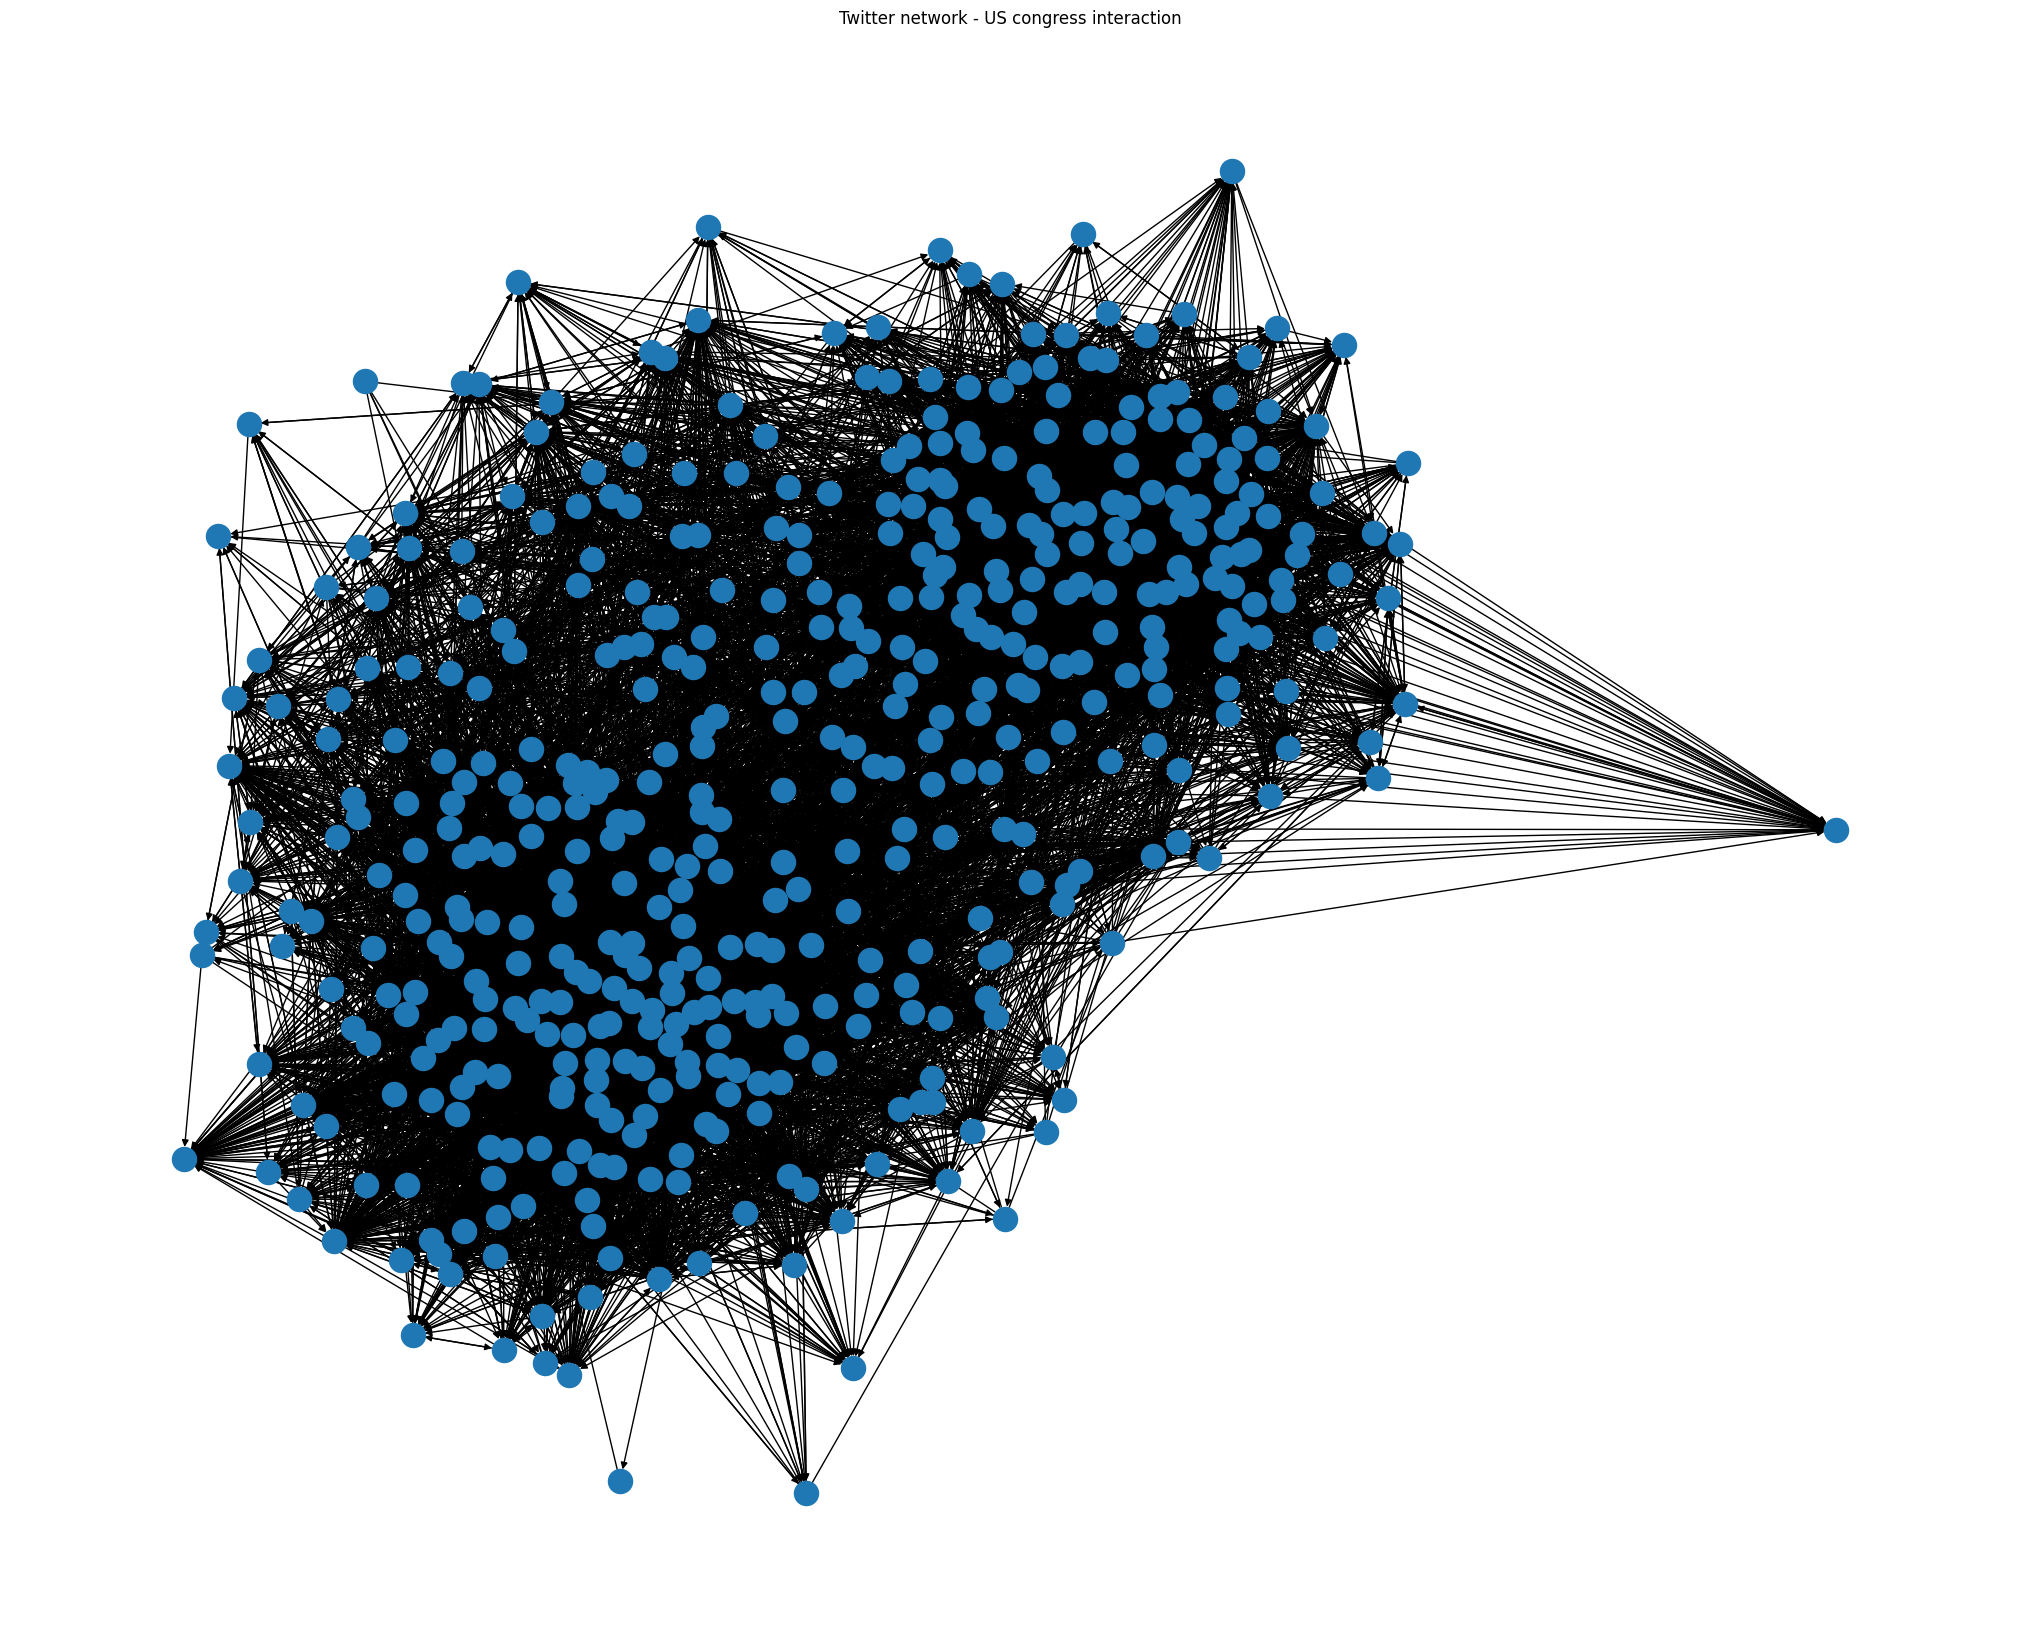

In [8]:
G = nx.read_edgelist('../data/congress_network/congress.edgelist', create_using=nx.DiGraph(), data=True)

plt.figure(figsize=(20, 16))

nx.draw(G)

plt.title('Twitter network - US congress interaction')
plt.show()

# General statistics and characteristics

In [12]:
def graph_characteristics(G):
    """
    Analyzes a directed social network graph and returns key statistics
    
    Parameters:
    G: NetworkX DiGraph object
    
    Returns:
    Dictionary with network statistics
    """
    
    stats = {}
    
    # 1. Basic Structure
    stats['num_nodes'] = G.number_of_nodes()
    stats['num_edges'] = G.number_of_edges()
    stats['is_directed'] = G.is_directed()

    if stats['is_directed'] == True:
        stats['is_directed'] = 'Yes'
    else:
        stats['is_directed'] = 'No:('
    
    # 2. Degree Statistics
    degrees = [d for n, d in G.degree()]
    stats['average_degree'] = sum(degrees) / len(degrees) if degrees else 0
    
    # 3. Density
    stats['density'] = nx.density(G)
    
    # 4. Clustering Coefficient
    # For directed graphs, we convert to undirected for clustering
    G_undirected = G.to_undirected()
    stats['clustering_coefficient'] = nx.average_clustering(G_undirected)
    
    # 5. Centrality Measures (top 10 nodes)
    in_centrality = nx.in_degree_centrality(G)
    out_centrality = nx.out_degree_centrality(G)
    total_centrality = nx.degree_centrality(G)
    
    stats['top_in_centrality'] = sorted(in_centrality.items(), 
                                        key=lambda x: x[1], 
                                        reverse=True)[:10]
    stats['top_out_centrality'] = sorted(out_centrality.items(), 
                                         key=lambda x: x[1], 
                                         reverse=True)[:10]
    stats['top_total_centrality'] = sorted(total_centrality.items(), 
                                         key=lambda x: x[1], 
                                         reverse=True)[:10]
    
    # 6. Strongly Connected Components
    sccs = list(nx.strongly_connected_components(G))
    stats['num_strongly_connected_components'] = len(sccs)
    stats['largest_scc_size'] = len(max(sccs, key=len)) if sccs else 0
    
    # 7. Largest Connected Component (weakly connected for directed graphs)
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len) if wccs else set()
    stats['largest_connected_component_size'] = len(largest_wcc)
    
    # 8. Average Path Length (only for largest connected component)
    if largest_wcc:
        largest_subgraph = G.subgraph(largest_wcc)
        # For directed graphs, convert to undirected for path length
        largest_undirected = largest_subgraph.to_undirected()
        
        if nx.is_connected(largest_undirected):
            stats['average_path_length'] = nx.average_shortest_path_length(largest_undirected)
        else:
            stats['average_path_length'] = None
    else:
        stats['average_path_length'] = None
    
    return stats


# Function to print statistics in a readable format
def print_network_stats(stats):
    """
    Prints network statistics in a formatted way
    """
    print("=" * 60)
    print("SOCIAL NETWORK GRAPH STATISTICS")
    print("=" * 60)
    
    print("\nBASIC STRUCTURE")
    print(f"  • Number of Nodes: {stats['num_nodes']}")
    print(f"  • Number of Edges: {stats['num_edges']}")
    print(f"  • Directed Graph: {stats['is_directed']}")
    
    print("\nCONNECTIVITY METRICS")
    print(f"  • Average Degree: {stats['average_degree']:.2f}")
    print(f"  • Density: {stats['density']:.4f}")
    print(f"  • Clustering Coefficient: {stats['clustering_coefficient']:.4f}")
    
    print("\n CENTRALITY (Top 10 most influential persons)")
    print("\n  IN-DEGREE:")
    for i, (node, centrality) in enumerate(stats['top_in_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nOUT-DEGREE:")
    for i, (node, centrality) in enumerate(stats['top_out_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nTOTAL DEGREE:")
    for i, (node, centrality) in enumerate(stats['top_total_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nCOMPONENT ANALYSIS")
    print(f"  • Number of Strongly Connected Components: {stats['num_strongly_connected_components']}")
    print(f"  • Largest SCC Size: {stats['largest_scc_size']}")
    print(f"  • Largest Connected Component: {stats['largest_connected_component_size']} nodes")
    
    if stats['average_path_length']:
        print(f"  • Average Path Length: {stats['average_path_length']:.2f}")
    else:
        print(f"  • Average Path Length: N/A (graph not connected)")
    
    print("=" * 60)

In [13]:
graph_measures = graph_characteristics(G)
print_network_stats(graph_measures)

SOCIAL NETWORK GRAPH STATISTICS

BASIC STRUCTURE
  • Number of Nodes: 475
  • Number of Edges: 13289
  • Directed Graph: Yes

CONNECTIVITY METRICS
  • Average Degree: 55.95
  • Density: 0.0590
  • Clustering Coefficient: 0.3014

 CENTRALITY (Top 10 most influential persons)

  IN-DEGREE:
    1. 322: 0.2679
    2. 208: 0.2553
    3. 190: 0.2532
    4. 111: 0.2300
    5. 254: 0.2278
    6. 385: 0.2278
    7. 269: 0.2236
    8. 192: 0.2215
    9. 147: 0.2046
    10. 303: 0.2046

OUT-DEGREE:
    1. 367: 0.4430
    2. 322: 0.3312
    3. 393: 0.2342
    4. 71: 0.2046
    5. 399: 0.1878
    6. 436: 0.1793
    7. 179: 0.1772
    8. 254: 0.1667
    9. 105: 0.1582
    10. 87: 0.1498

TOTAL DEGREE:
    1. 322: 0.5992
    2. 367: 0.5506
    3. 393: 0.4008
    4. 254: 0.3945
    5. 208: 0.3840
    6. 303: 0.3439
    7. 269: 0.3439
    8. 190: 0.3312
    9. 399: 0.3207
    10. 111: 0.3122

COMPONENT ANALYSIS
  • Number of Strongly Connected Components: 7
  • Largest SCC Size: 469
  • Largest Connect

In [14]:
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
from networkx.algorithms import community

def detect_communities(G, method='louvain'):
    """
    Detects communities in a directed graph using various algorithms
    
    Parameters:
    G: NetworkX DiGraph object
    method: str - 'louvain', 'label_propagation', 'girvan_newman', or 'greedy_modularity'
    
    Returns:
    Dictionary mapping nodes to community IDs
    """
    
    # Convert directed graph to undirected for community detection
    G_undirected = G.to_undirected()
    
    print(f"Detecting communities using {method.upper()} method...")
    
    if method == 'louvain':
        # Louvain requires the python-louvain package
        # We'll use greedy_modularity_communities as an alternative
        communities_generator = community.greedy_modularity_communities(G_undirected, weight='weight')
        communities = list(communities_generator)
        
    elif method == 'label_propagation':
        communities_generator = community.label_propagation_communities(G_undirected)
        communities = list(communities_generator)
        
    elif method == 'girvan_newman':
        # Girvan-Newman returns a generator of community divisions
        # We take the first level (most granular)
        communities_generator = community.girvan_newman(G_undirected)
        # Get a reasonable number of communities (tune this parameter)
        for _ in range(3):  # Adjust iterations for more/fewer communities
            try:
                communities = next(communities_generator)
            except StopIteration:
                break
        communities = list(communities)
        
    elif method == 'greedy_modularity':
        communities_generator = community.greedy_modularity_communities(G_undirected)
        communities = list(communities_generator)
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Convert to dictionary format: {node: community_id}
    node_to_community = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_community[node] = i
    
    return node_to_community, communities


def analyze_communities(G, node_to_community, communities):
    """
    Analyzes community structure and returns statistics
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    communities: list of sets, each set contains nodes in a community
    
    Returns:
    Dictionary with community statistics
    """
    
    stats = {}
    stats['num_communities'] = len(communities)
    stats['community_sizes'] = [len(comm) for comm in communities]
    stats['largest_community'] = max(stats['community_sizes'])
    stats['smallest_community'] = min(stats['community_sizes'])
    stats['average_community_size'] = np.mean(stats['community_sizes'])
    
    # Calculate modularity
    G_undirected = G.to_undirected()
    stats['modularity'] = community.modularity(G_undirected, communities)
    
    # Get top nodes in each community (by degree)
    stats['community_details'] = []
    for i, comm in enumerate(communities):
        subgraph = G.subgraph(comm)
        degrees = dict(subgraph.degree())
        top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        
        stats['community_details'].append({
            'id': i,
            'size': len(comm),
            'nodes': list(comm),
            'top_nodes': top_nodes
        })
    
    return stats


def print_community_stats(stats):
    """
    Prints community detection statistics in a formatted way
    """
    
    print(f"\nOVERALL STATISTICS")
    print(f"  • Number of Communities: {stats['num_communities']}")
    print(f"  • Modularity Score: {stats['modularity']:.4f}")
    print(f"  • Average Community Size: {stats['average_community_size']:.2f} nodes")
    print(f"  • Largest Community: {stats['largest_community']} nodes")
    print(f"  • Smallest Community: {stats['smallest_community']} nodes")
    
    print(f"\nCOMMUNITY DETAILS (sorted by size)")
    
    # Sort communities by size
    sorted_communities = sorted(stats['community_details'], 
                               key=lambda x: x['size'], 
                               reverse=True)
    
    for comm in sorted_communities:
        print(f"\n  Community {comm['id']} ({comm['size']} nodes)")
        print(f"    Top nodes by degree:")
        for node, degree in comm['top_nodes']:
            print(f"      • {node} (degree: {degree})")
    
    print("=" * 60)


def visualize_communities(G, node_to_community, title="Community Detection", 
                         figsize=(16, 12), layout='spring'):
    """
    Visualizes the graph with communities highlighted in different colors
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    title: str - plot title
    figsize: tuple - figure size
    layout: str - 'spring', 'kamada_kawai', or 'circular'
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Choose layout algorithm
    if layout == 'spring':
        pos = nx.spring_layout(G, k=1, iterations=50, seed=42)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    
    # Get unique communities and assign colors
    unique_communities = sorted(set(node_to_community.values()))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
    community_colors = {comm_id: colors[i] for i, comm_id in enumerate(unique_communities)}
    
    # Map each node to its color
    node_colors = [community_colors[node_to_community[node]] for node in G.nodes()]
    
    # Calculate node sizes based on degree
    node_sizes = [G.degree(node) * 100 + 100 for node in G.nodes()]
    
    # PLOT 1: Full network with communities
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.8, 
                          edgecolors='black', linewidths=1.5, ax=ax1)
    
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          alpha=0.2, arrows=True, 
                          arrowsize=10, arrowstyle='->', ax=ax1)
    
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', ax=ax1)
    
    ax1.set_title(f"{title}\n({len(unique_communities)} communities detected)", 
                  fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # PLOT 2: Community distribution (bar chart)
    community_sizes = {}
    for node, comm in node_to_community.items():
        community_sizes[comm] = community_sizes.get(comm, 0) + 1
    
    sorted_communities = sorted(community_sizes.items())
    comm_ids = [f"C{c}" for c, _ in sorted_communities]
    sizes = [s for _, s in sorted_communities]
    bar_colors = [community_colors[c] for c, _ in sorted_communities]
    
    ax2.bar(comm_ids, sizes, color=bar_colors, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Community ID', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Nodes', fontsize=12, fontweight='bold')
    ax2.set_title('Community Size Distribution', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Rotate x-axis labels if many communities
    if len(comm_ids) > 10:
        ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


def visualize_largest_communities(G, node_to_community, top_n=3, figsize=(18, 6)):
    """
    Visualizes the largest N communities separately for detailed inspection
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    top_n: int - number of largest communities to visualize
    """
    
    # Count nodes in each community
    community_sizes = {}
    for node, comm in node_to_community.items():
        community_sizes[comm] = community_sizes.get(comm, 0) + 1
    
    # Get top N largest communities
    largest_communities = sorted(community_sizes.items(), 
                                key=lambda x: x[1], 
                                reverse=True)[:top_n]
    
    fig, axes = plt.subplots(1, top_n, figsize=figsize)
    
    if top_n == 1:
        axes = [axes]
    
    colors = plt.cm.Set3(np.linspace(0, 1, top_n))
    
    for idx, (comm_id, size) in enumerate(largest_communities):
        # Get nodes in this community
        comm_nodes = [node for node, comm in node_to_community.items() if comm == comm_id]
        subgraph = G.subgraph(comm_nodes)
        
        # Layout for this subgraph
        pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)
        
        # Node sizes based on degree within community
        node_sizes = [subgraph.degree(node) * 150 + 100 for node in subgraph.nodes()]
        
        # Draw
        nx.draw_networkx_nodes(subgraph, pos, node_color=[colors[idx]], 
                              node_size=node_sizes, alpha=0.8, 
                              edgecolors='black', linewidths=1.5, ax=axes[idx])
        
        nx.draw_networkx_edges(subgraph, pos, edge_color='gray', 
                              alpha=0.3, arrows=True, 
                              arrowsize=10, ax=axes[idx])
        
        nx.draw_networkx_labels(subgraph, pos, font_size=8, 
                               font_weight='bold', ax=axes[idx])
        
        axes[idx].set_title(f"Community {comm_id}\n({size} nodes)", 
                           fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.suptitle('Largest Communities (Detailed View)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# MAIN EXECUTION FUNCTION
def perform_community_analysis(G, method='greedy_modularity'):
    """
    Complete community detection and visualization pipeline
    
    Parameters:
    G: NetworkX DiGraph
    method: str - community detection method
    """
    
    print(f"\n{'='*60}")
    print(f"Starting Community Detection Analysis")
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"{'='*60}\n")
    
    # Step 1: Detect communities
    node_to_community, communities = detect_communities(G, method=method)
    
    # Step 2: Analyze communities
    stats = analyze_communities(G, node_to_community, communities)
    
    # Step 3: Print statistics
    print_community_stats(stats)
    
    # Step 4: Visualize
    print("\nGenerating visualizations...")
    visualize_communities(G, node_to_community, 
                         title=f"IT Jobs Network - {method.upper()} Method")
    
    # Step 5: Detailed view of largest communities
    if stats['num_communities'] >= 3:
        visualize_largest_communities(G, node_to_community, top_n=min(3, stats['num_communities']))
    
    return node_to_community, communities, stats


Starting Community Detection Analysis
Graph: 475 nodes, 13289 edges

Detecting communities using GREEDY_MODULARITY method...

OVERALL STATISTICS
  • Number of Communities: 3
  • Modularity Score: 0.3998
  • Average Community Size: 158.33 nodes
  • Largest Community: 248 nodes
  • Smallest Community: 45 nodes

COMMUNITY DETAILS (sorted by size)

  Community 0 (248 nodes)
    Top nodes by degree:
      • 367 (degree: 186)
      • 393 (degree: 185)
      • 254 (degree: 171)
      • 303 (degree: 155)
      • 147 (degree: 141)

  Community 1 (182 nodes)
    Top nodes by degree:
      • 322 (degree: 256)
      • 208 (degree: 168)
      • 269 (degree: 158)
      • 399 (degree: 145)
      • 190 (degree: 136)

  Community 2 (45 nodes)
    Top nodes by degree:
      • 17 (degree: 50)
      • 72 (degree: 39)
      • 32 (degree: 37)
      • 66 (degree: 36)
      • 26 (degree: 33)

Generating visualizations...


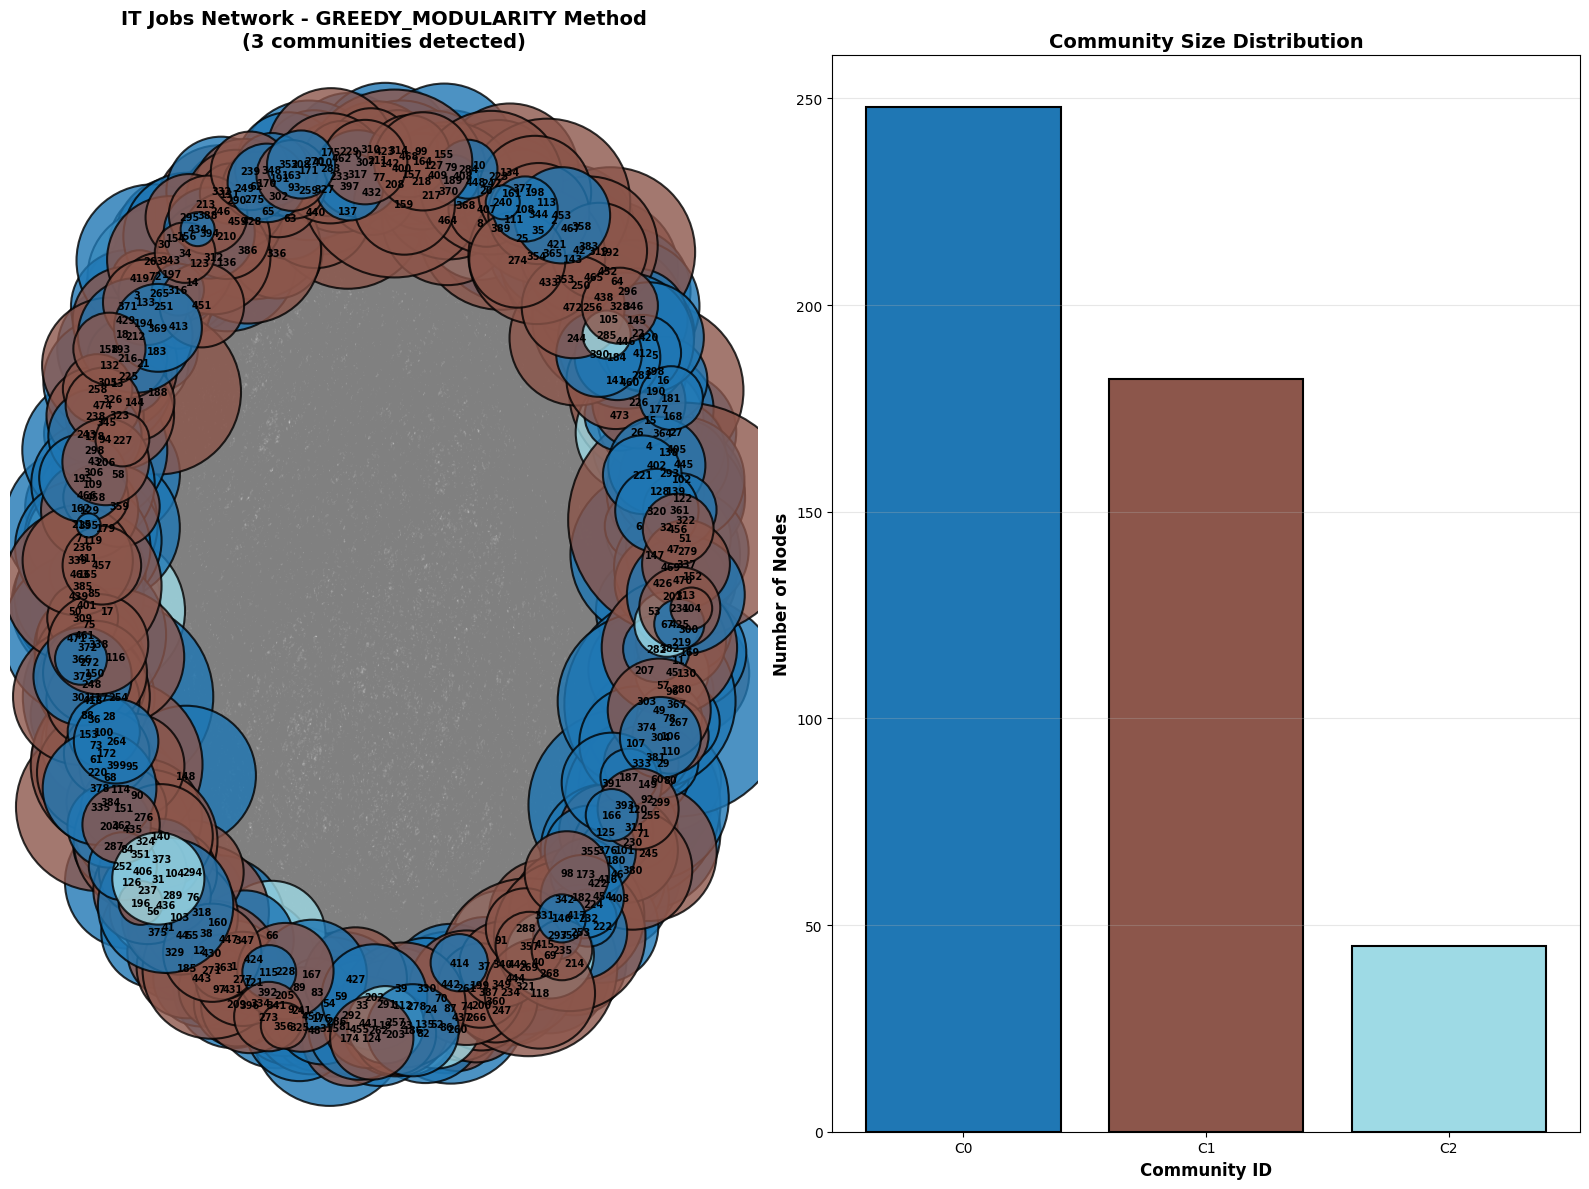

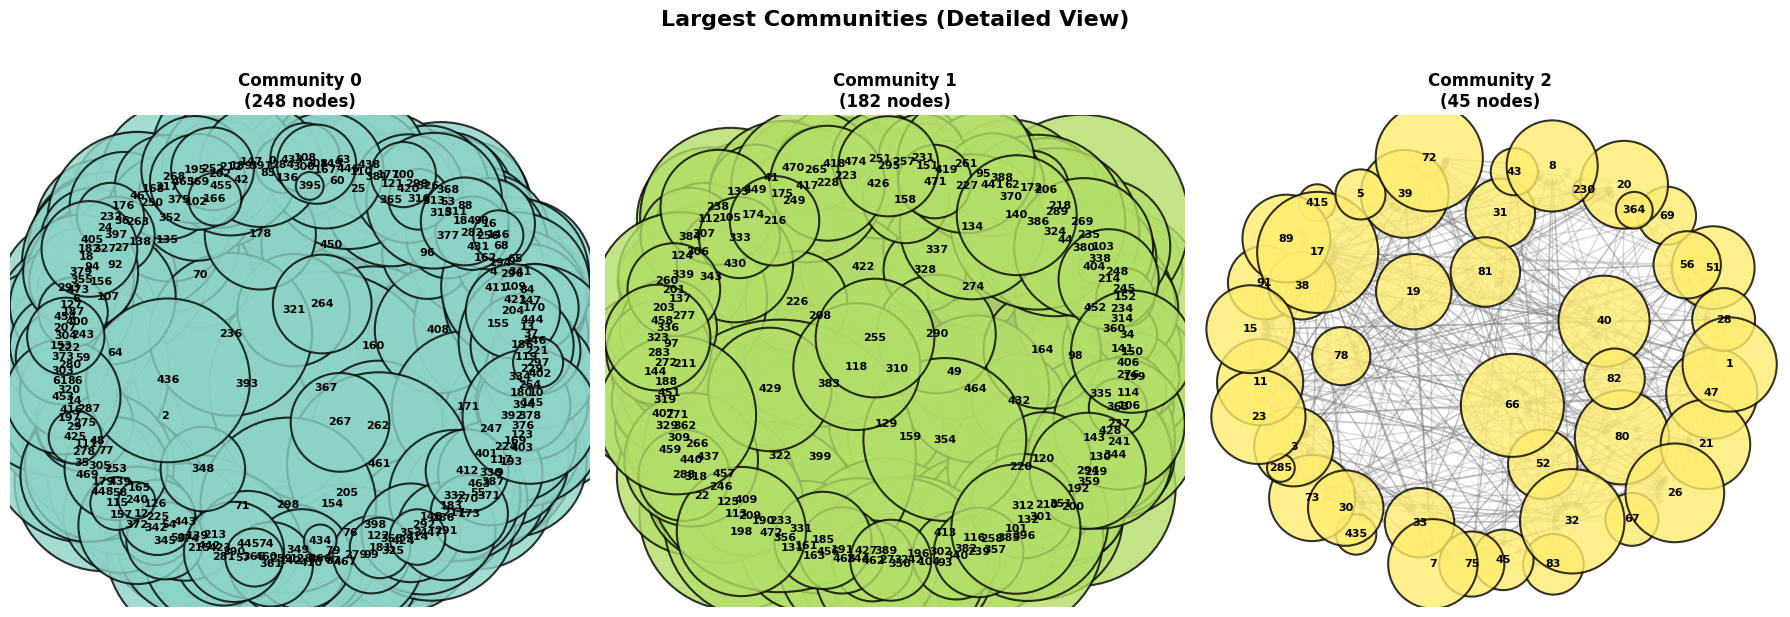

{'6': 0,
 '253': 0,
 '111': 0,
 '119': 0,
 '202': 0,
 '361': 0,
 '411': 0,
 '372': 0,
 '420': 0,
 '320': 0,
 '177': 0,
 '24': 0,
 '55': 0,
 '109': 0,
 '84': 0,
 '280': 0,
 '42': 0,
 '48': 0,
 '77': 0,
 '424': 0,
 '252': 0,
 '187': 0,
 '317': 0,
 '292': 0,
 '369': 0,
 '365': 0,
 '27': 0,
 '355': 0,
 '182': 0,
 '63': 0,
 '448': 0,
 '232': 0,
 '304': 0,
 '37': 0,
 '443': 0,
 '167': 0,
 '264': 0,
 '293': 0,
 '263': 0,
 '128': 0,
 '10': 0,
 '0': 0,
 '379': 0,
 '122': 0,
 '467': 0,
 '282': 0,
 '180': 0,
 '267': 0,
 '168': 0,
 '225': 0,
 '86': 0,
 '390': 0,
 '250': 0,
 '135': 0,
 '455': 0,
 '100': 0,
 '236': 0,
 '402': 0,
 '442': 0,
 '281': 0,
 '247': 0,
 '217': 0,
 '368': 0,
 '60': 0,
 '157': 0,
 '305': 0,
 '154': 0,
 '256': 0,
 '453': 0,
 '446': 0,
 '14': 0,
 '327': 0,
 '387': 0,
 '243': 0,
 '25': 0,
 '2': 0,
 '352': 0,
 '297': 0,
 '433': 0,
 '325': 0,
 '445': 0,
 '156': 0,
 '35': 0,
 '74': 0,
 '12': 0,
 '434': 0,
 '186': 0,
 '58': 0,
 '316': 0,
 '375': 0,
 '136': 0,
 '347': 0,
 '377': 0,
 

In [15]:
node_to_community, communities, stats = perform_community_analysis(G, method='greedy_modularity')
node_to_community

_WORK IN PROGRESS_

**Since the size of the LCC is almost the entire graph, we are taking the biggest community of the graph for the upcoming analysis in order to save computational resources**

In [16]:
#G_2 = G

# Centrality measures

### **Betwenness centrality**

In [17]:
def calculate_betweenness(G: nx.DiGraph, top_n: int = 10) -> dict:
    """
    Calculates betweenness centrality for a directed graph and displays the top N
    members with the highest centrality.

    Args:
        G (nx.DiGraph): The directed, weighted graph (e.g., Congress Twitter network).
        top_n (int): The number of top members to display.

    Returns:
        dict: A dictionary of {node: betweenness_score} for the entire graph.
    """
    print(f"**Calculating Betweenness Centrality for {G.number_of_nodes()} members...**\n")

    # Use the 'weight' attribute if available, although standard betweenness 
    # often ignores weights for directed graphs unless specified differently 
    # (nx.betweenness_centrality can use weights via 'weight' argument for 
    # shortest path calculation, but here we treat it as standard unweighted for robustness).
    betweenness = nx.betweenness_centrality(G, normalized=True, weight=None) 
    
    # Sort the results in descending order
    sorted_betweenness = dict(sorted(betweenness.items(), key=lambda item: item[1], reverse=True))
    
    # Display the top N
    print(f"***Top {top_n} Members by Betweenness Centrality (Highest Bridge/Broker Score)***")
    for i, (node, score) in enumerate(list(sorted_betweenness.items())[:top_n]):
        print(f"Rank {i+1}: Node '{node}' - Betweenness: {score:.4f}")
        
    return betweenness

In [18]:
betweenness = calculate_betweenness(G)
print(betweenness)

**Calculating Betweenness Centrality for 475 members...**

***Top 10 Members by Betweenness Centrality (Highest Bridge/Broker Score)***
Rank 1: Node '322' - Betweenness: 0.0730
Rank 2: Node '367' - Betweenness: 0.0414
Rank 3: Node '254' - Betweenness: 0.0307
Rank 4: Node '393' - Betweenness: 0.0272
Rank 5: Node '335' - Betweenness: 0.0178
Rank 6: Node '208' - Betweenness: 0.0169
Rank 7: Node '17' - Betweenness: 0.0165
Rank 8: Node '303' - Betweenness: 0.0155
Rank 9: Node '461' - Betweenness: 0.0143
Rank 10: Node '113' - Betweenness: 0.0127
{'0': 0.001092706065870422, '4': 0.002138609423422786, '12': 0.0036918360372507394, '18': 0.0009745765263505249, '25': 0.004577057598935396, '30': 0.0034153445254497734, '46': 0.007453180424329784, '55': 0.0037435910847693587, '58': 0.008630958955931908, '59': 0.004868133406734935, '74': 0.003578136932051915, '76': 0.0016551045251612447, '77': 0.002739112663291009, '85': 0.0024090507175677906, '86': 0.0016817971104330217, '87': 0.008416557908474578, 

In [19]:
#lcc_bc = calculate_betweenness(G_2)

In [20]:
def display_graph_by_betweenness(G: nx.DiGraph, betweenness_scores: dict):
    """
    Displays the directed graph, coloring and sizing the nodes based on
    their betweenness centrality score.

    Args:
        G (nx.DiGraph): The directed graph.
        betweenness_scores (dict): The dictionary of {node: betweenness_score} 
                                   from calculate_betweenness.
    """
    if not betweenness_scores:
        print("Error: Betweenness scores are empty. Please run Function 1 first.")
        return

    print("\n**Generating Graph Visualization...**")

    # 1. Prepare Node Attributes (Size and Color)
    
    # Extract scores into a list based on the order of nodes in the graph
    node_list = list(G.nodes())
    scores = np.array([betweenness_scores[node] for node in node_list])
    
    # Normalize scores for color mapping (0 to 1)
    if scores.max() > 0:
        normalized_scores = scores / scores.max()
    else:
        normalized_scores = scores # All zero if max is zero
        
    # Scale scores for node size (e.g., from 100 to 2000)
    # Adding a base size to ensure visibility of nodes with zero betweenness.
    base_size = 100
    scale_factor = 2500
    node_sizes = base_size + (scores * scale_factor)

    # 2. Setup Plot
    plt.figure(figsize=(15, 12))
    
    # Calculate a layout (Spectral is good for showing disconnected components)
    pos = nx.spring_layout(G, k=0.1, iterations=50, seed=42) # k adjusts distance between nodes

    # 3. Draw Nodes and Edges
    
    # Draw nodes, colored by centrality (using a 'viridis' colormap)
    nodes = nx.draw_networkx_nodes(
        G, pos, 
        node_size=node_sizes, 
        node_color=normalized_scores, 
        cmap=plt.cm.viridis,
        alpha=0.8
    )
    
    # Draw edges (directed graph)
    nx.draw_networkx_edges(
        G, pos, 
        arrowstyle='-|>', 
        arrowsize=10, 
        edge_color='gray', 
        alpha=0.2
    )
    
    # Optional: Draw a few labels for the highest centrality nodes
    top_nodes = list(dict(sorted(betweenness_scores.items(), key=lambda item: item[1], reverse=True)).keys())[:5]
    labels = {node: node for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_color='red')

    # 4. Add Colorbar and Title
    if nodes is not None:
        cbar = plt.colorbar(nodes)
        cbar.set_label('Betweenness Centrality (Normalized)')

    plt.title("Congress Twitter Network: Nodes Sized and Colored by Betweenness Centrality")
    plt.axis('off') # Hide the axis
    plt.show()


**Generating Graph Visualization...**


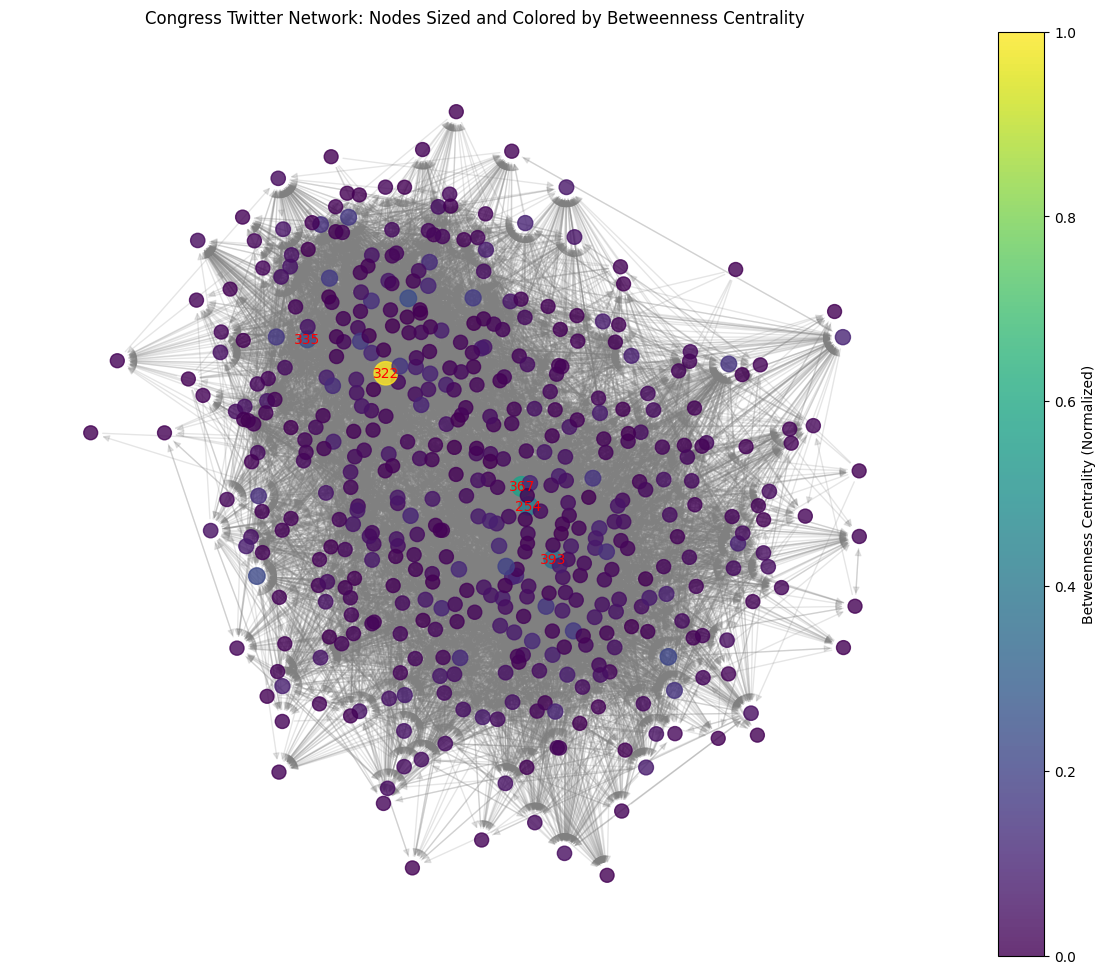

In [21]:
betwenness_graph = display_graph_by_betweenness(G, betweenness)
betwenness_graph

# PageRank

In [22]:
def calculate_pagerank(G: nx.DiGraph, alpha: float = 0.85, max_iter: int = 100, 
                       tol: float = 1.0e-6, top_n: int = 10) -> dict:
    """
    Calculates PageRank centrality for a directed graph.
    
    PageRank measures node importance based on the structure of incoming links.
    A node is important if it is linked to by other important nodes.
    
    Args:
        G (nx.DiGraph): The directed graph
        alpha (float): Damping parameter (default 0.85)
        max_iter (int): Maximum number of iterations
        tol (float): Error tolerance for convergence
        top_n (int): Number of top members to display
    
    Returns:
        dict: A dictionary of {node: pagerank_score} for the entire graph
    """
    print(f"**Calculating PageRank for {G.number_of_nodes()} members...**")
    print(f"Parameters: alpha={alpha}, max_iter={max_iter}, tolerance={tol}\n")
    
    # Calculate PageRank
    pagerank = nx.pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol, weight='weight')
    
    # Sort the results in descending order
    sorted_pagerank = dict(sorted(pagerank.items(), key=lambda item: item[1], reverse=True))
    
    # Display the top N
    print(f"***Top {top_n} Members by PageRank (Highest Influence Score)***")
    for i, (node, score) in enumerate(list(sorted_pagerank.items())[:top_n]):
        print(f"Rank {i+1}: Node '{node}' - PageRank: {score:.6f}")
    
    print(f"\n**PageRank Statistics:**")
    scores = list(pagerank.values())
    print(f"  • Mean PageRank: {np.mean(scores):.6f}")
    print(f"  • Median PageRank: {np.median(scores):.6f}")
    print(f"  • Max PageRank: {np.max(scores):.6f}")
    print(f"  • Min PageRank: {np.min(scores):.6f}")
    print(f"  • Std Dev: {np.std(scores):.6f}")
    
    return pagerank


def visualize_pagerank(G: nx.DiGraph, pagerank_scores: dict, top_n_highlight: int = 20):
    """
    Visualizes the directed graph with nodes colored and sized by PageRank.
    
    Args:
        G (nx.DiGraph): The directed graph
        pagerank_scores (dict): Dictionary of {node: pagerank_score}
        top_n_highlight (int): Number of top nodes to label
    """
    if not pagerank_scores:
        print("Error: PageRank scores are empty. Please run calculate_pagerank first.")
        return
    
    print("\n**Generating PageRank Visualization...**")
    
    # Prepare node attributes
    node_list = list(G.nodes())
    scores = np.array([pagerank_scores[node] for node in node_list])
    
    # Normalize scores for color mapping (0 to 1)
    if scores.max() > 0:
        normalized_scores = scores / scores.max()
    else:
        normalized_scores = scores
    
    # Scale scores for node size
    base_size = 100
    scale_factor = 5000
    node_sizes = base_size + (scores * scale_factor)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Layout
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)
    
    # PLOT 1: Network visualization
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=normalized_scores,
        cmap=plt.cm.plasma,
        alpha=0.8,
        ax=ax1
    )
    
    nx.draw_networkx_edges(
        G, pos,
        arrowstyle='-|>',
        arrowsize=8,
        edge_color='gray',
        alpha=0.15,
        ax=ax1
    )
    
    # Label top nodes
    top_nodes = list(dict(sorted(pagerank_scores.items(), 
                                 key=lambda item: item[1], 
                                 reverse=True)).keys())[:top_n_highlight]
    labels = {node: str(node) for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, 
                           font_color='white', font_weight='bold', ax=ax1)
    
    if nodes is not None:
        cbar = plt.colorbar(nodes, ax=ax1)
        cbar.set_label('PageRank Score (Normalized)', fontsize=12)
    
    ax1.set_title("Congress Twitter Network: Nodes Sized and Colored by PageRank", 
                  fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # PLOT 2: PageRank distribution histogram
    scores_sorted = sorted(pagerank_scores.values(), reverse=True)
    ax2.hist(scores_sorted, bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(scores_sorted), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(scores_sorted):.6f}')
    ax2.axvline(np.median(scores_sorted), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(scores_sorted):.6f}')
    
    ax2.set_xlabel('PageRank Score', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('PageRank Score Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [23]:
def compare_pagerank_with_degree(G: nx.DiGraph, pagerank_scores: dict, top_n: int = 15):
    """
    Compares PageRank with in-degree, out-degree, and total degree centrality.
    
    Args:
        G (nx.DiGraph): The directed graph
        pagerank_scores (dict): Dictionary of {node: pagerank_score}
        top_n (int): Number of top nodes to compare
    """
    print(f"\n**Comparing PageRank with Degree Centralities (Top {top_n} nodes)**\n")
    
    # Calculate degree centralities
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())
    total_degree = dict(G.degree())
    
    # Get top nodes by each metric
    top_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_in_degree = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_out_degree = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_total_degree = sorted(total_degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    # Create comparison dataframe
    comparison_data = []
    for i in range(top_n):
        comparison_data.append({
            'Rank': i + 1,
            'PageRank_Node': top_pagerank[i][0],
            'PageRank_Score': f"{top_pagerank[i][1]:.6f}",
            'InDegree_Node': top_in_degree[i][0],
            'InDegree_Count': top_in_degree[i][1],
            'OutDegree_Node': top_out_degree[i][0],
            'OutDegree_Count': top_out_degree[i][1],
            'TotalDegree_Node': top_total_degree[i][0],
            'TotalDegree_Count': top_total_degree[i][1]
        })
    
    # Print comparison table
    print("=" * 120)
    print(f"{'Rank':<6} {'PageRank':<12} {'PR Score':<12} {'In-Degree':<12} {'In-Count':<10} "
          f"{'Out-Degree':<12} {'Out-Count':<10} {'Total Deg':<12} {'Tot-Count':<10}")
    print("=" * 120)
    
    for row in comparison_data:
        print(f"{row['Rank']:<6} {row['PageRank_Node']:<12} {row['PageRank_Score']:<12} "
              f"{row['InDegree_Node']:<12} {row['InDegree_Count']:<10} "
              f"{row['OutDegree_Node']:<12} {row['OutDegree_Count']:<10} "
              f"{row['TotalDegree_Node']:<12} {row['TotalDegree_Count']:<10}")
    
    print("=" * 120)
    
    # Analyze overlap between metrics
    pagerank_nodes = set([node for node, _ in top_pagerank])
    in_degree_nodes = set([node for node, _ in top_in_degree])
    out_degree_nodes = set([node for node, _ in top_out_degree])
    total_degree_nodes = set([node for node, _ in top_total_degree])
    
    print(f"\n**Overlap Analysis (Top {top_n} nodes):**")
    print(f"  • PageRank ∩ In-Degree: {len(pagerank_nodes & in_degree_nodes)} nodes")
    print(f"  • PageRank ∩ Out-Degree: {len(pagerank_nodes & out_degree_nodes)} nodes")
    print(f"  • PageRank ∩ Total Degree: {len(pagerank_nodes & total_degree_nodes)} nodes")
    print(f"  • All four metrics: {len(pagerank_nodes & in_degree_nodes & out_degree_nodes & total_degree_nodes)} nodes")


***TOP 10 MEMBERS BY PAGERANK (Most Influential)***
------------------------------------------------------------
  Rank 1: Node '322' - PageRank: 0.016696
  Rank 2: Node '147' - PageRank: 0.012845
  Rank 3: Node '389' - PageRank: 0.011028
  Rank 4: Node '269' - PageRank: 0.010660
  Rank 5: Node '215' - PageRank: 0.010580
  Rank 6: Node '208' - PageRank: 0.008885
  Rank 7: Node '92' - PageRank: 0.008246
  Rank 8: Node '246' - PageRank: 0.008157
  Rank 9: Node '303' - PageRank: 0.008033
  Rank 10: Node '113' - PageRank: 0.008026

**PAGERANK STATISTICS:**
  • Mean PageRank: 0.002105
  • Median PageRank: 0.001519
  • Max PageRank: 0.016696
  • Min PageRank: 0.000316
  • Standard Deviation: 0.001944

**GENERATING PAGERANK VISUALIZATIONS...**



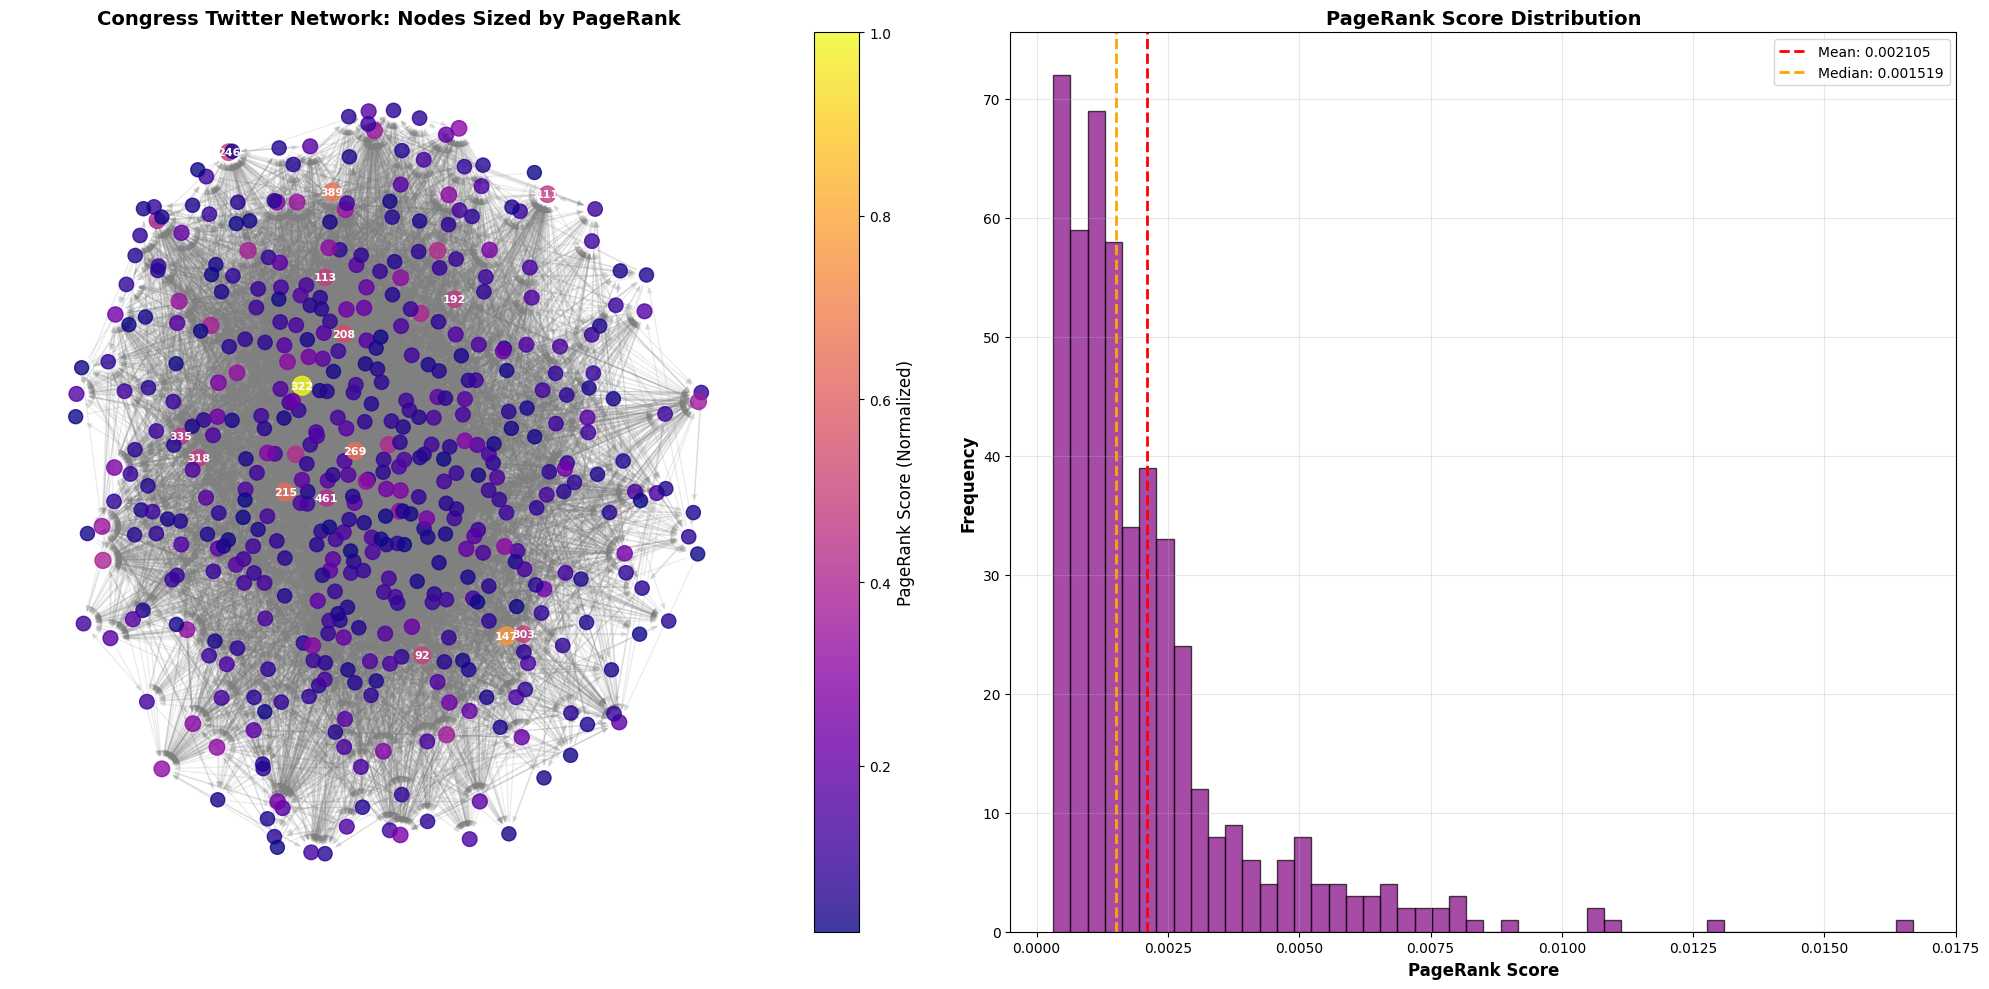

In [24]:
# Calculate PageRank with standard parameters
pagerank_scores = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1.0e-6, weight='weight')

# Sort by PageRank score
sorted_pagerank = dict(sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True))

# Display Top 10
print("***TOP 10 MEMBERS BY PAGERANK (Most Influential)***")
print("-" * 60)
for i, (node, score) in enumerate(list(sorted_pagerank.items())[:10]):
    print(f"  Rank {i+1}: Node '{node}' - PageRank: {score:.6f}")

# Statistics
scores = list(pagerank_scores.values())
print(f"\n**PAGERANK STATISTICS:**")
print(f"  • Mean PageRank: {np.mean(scores):.6f}")
print(f"  • Median PageRank: {np.median(scores):.6f}")
print(f"  • Max PageRank: {np.max(scores):.6f}")
print(f"  • Min PageRank: {np.min(scores):.6f}")
print(f"  • Standard Deviation: {np.std(scores):.6f}")

print("\n**GENERATING PAGERANK VISUALIZATIONS...**\n")

# Prepare node attributes
node_list = list(G.nodes())
pr_values = np.array([pagerank_scores[node] for node in node_list])

# Normalize for colors
normalized_pr = pr_values / pr_values.max()

# Size nodes by PageRank
node_sizes = 100 + (pr_values * 5000)

# Create figure
fig = plt.figure(figsize=(20, 10))

# Layout
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# SUBPLOT 1: Network with PageRank
ax1 = plt.subplot(1, 2, 1)
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=normalized_pr,
    cmap=plt.cm.plasma,
    alpha=0.8,
    ax=ax1
)

nx.draw_networkx_edges(
    G, pos,
    arrowstyle='-|>',
    arrowsize=8,
    edge_color='gray',
    alpha=0.15,
    ax=ax1
)

# Label top 15 nodes
top_15_nodes = list(sorted_pagerank.keys())[:15]
labels = {node: str(node) for node in top_15_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, 
                       font_color='white', font_weight='bold', ax=ax1)

cbar = plt.colorbar(nodes, ax=ax1)
cbar.set_label('PageRank Score (Normalized)', fontsize=12)

ax1.set_title("Congress Twitter Network: Nodes Sized by PageRank", 
              fontsize=14, fontweight='bold')
ax1.axis('off')

# SUBPLOT 2: PageRank Distribution
ax2 = plt.subplot(1, 2, 2)
scores_sorted = sorted(pagerank_scores.values(), reverse=True)
ax2.hist(scores_sorted, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax2.axvline(np.mean(scores_sorted), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(scores_sorted):.6f}')
ax2.axvline(np.median(scores_sorted), color='orange', linestyle='--', 
            linewidth=2, label=f'Median: {np.median(scores_sorted):.6f}')

ax2.set_xlabel('PageRank Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('PageRank Score Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CENTRALITY METRICS COMPARISON

In [25]:
def comprehensive_centrality_comparison(G: nx.DiGraph, pagerank_scores: dict, 
                                       betweenness_scores: dict, top_n: int = 20):
    """
    Comprehensive comparison of all centrality metrics:
    - PageRank
    - Betweenness Centrality
    - In-Degree Centrality
    - Out-Degree Centrality
    - Closeness Centrality
    
    Args:
        G (nx.DiGraph): The directed graph
        pagerank_scores (dict): Dictionary of PageRank scores
        betweenness_scores (dict): Dictionary of Betweenness scores
        top_n (int): Number of top nodes to analyze
    """
    print(f"\n{'='*80}")
    print(f"COMPREHENSIVE CENTRALITY ANALYSIS (Top {top_n} Nodes)")
    print(f"{'='*80}\n")
    
    # Calculate all centralities
    in_centrality = nx.in_degree_centrality(G)
    out_centrality = nx.out_degree_centrality(G)
    
    # Closeness centrality (using weakly connected component)
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len) if wccs else set()
    if largest_wcc:
        subgraph = G.subgraph(largest_wcc)
        closeness = nx.closeness_centrality(subgraph)
    else:
        closeness = {node: 0 for node in G.nodes()}
    
    # Create comprehensive data structure
    all_nodes = list(G.nodes())
    centrality_data = []
    
    for node in all_nodes:
        centrality_data.append({
            'node': node,
            'pagerank': pagerank_scores.get(node, 0),
            'betweenness': betweenness_scores.get(node, 0),
            'in_degree': in_centrality.get(node, 0),
            'out_degree': out_centrality.get(node, 0),
            'closeness': closeness.get(node, 0)
        })
    
    # Sort by PageRank
    centrality_data.sort(key=lambda x: x['pagerank'], reverse=True)
    
    # Print top nodes with all metrics
    print(f"{'Node':<8} {'PageRank':<12} {'Betweenness':<14} {'In-Degree':<12} "
          f"{'Out-Degree':<12} {'Closeness':<12}")
    print("=" * 80)
    
    for i, data in enumerate(centrality_data[:top_n]):
        print(f"{data['node']:<8} {data['pagerank']:<12.6f} {data['betweenness']:<14.6f} "
              f"{data['in_degree']:<12.4f} {data['out_degree']:<12.4f} {data['closeness']:<12.4f}")
    
    print("=" * 80)
    
    # Correlation analysis
    print("\n**Correlation Analysis Between Centrality Metrics:**")
    
    import scipy.stats as stats
    
    pr_values = [d['pagerank'] for d in centrality_data]
    bt_values = [d['betweenness'] for d in centrality_data]
    in_values = [d['in_degree'] for d in centrality_data]
    out_values = [d['out_degree'] for d in centrality_data]
    cl_values = [d['closeness'] for d in centrality_data]
    
    correlations = {
        'PageRank vs Betweenness': stats.spearmanr(pr_values, bt_values)[0],
        'PageRank vs In-Degree': stats.spearmanr(pr_values, in_values)[0],
        'PageRank vs Out-Degree': stats.spearmanr(pr_values, out_values)[0],
        'PageRank vs Closeness': stats.spearmanr(pr_values, cl_values)[0],
        'Betweenness vs In-Degree': stats.spearmanr(bt_values, in_values)[0],
        'Betweenness vs Out-Degree': stats.spearmanr(bt_values, out_values)[0]
    }
    
    for pair, corr in correlations.items():
        print(f"  • {pair}: {corr:.4f}")
    
    # Visualization
    visualize_centrality_comparison(centrality_data, top_n)
    
    return centrality_data


def visualize_centrality_comparison(centrality_data: list, top_n: int = 20):
    """
    Creates visualizations comparing different centrality metrics.
    
    Args:
        centrality_data (list): List of dictionaries with all centrality scores
        top_n (int): Number of top nodes to visualize
    """
    top_data = centrality_data[:top_n]
    nodes = [str(d['node']) for d in top_data]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Centrality Metrics Comparison (Top 20 Nodes)', 
                 fontsize=16, fontweight='bold')
    
    # PageRank
    pr_scores = [d['pagerank'] for d in top_data]
    axes[0, 0].barh(nodes, pr_scores, color='purple', alpha=0.7)
    axes[0, 0].set_xlabel('PageRank Score')
    axes[0, 0].set_title('PageRank Centrality')
    axes[0, 0].invert_yaxis()
    
    # Betweenness
    bt_scores = [d['betweenness'] for d in top_data]
    axes[0, 1].barh(nodes, bt_scores, color='orange', alpha=0.7)
    axes[0, 1].set_xlabel('Betweenness Score')
    axes[0, 1].set_title('Betweenness Centrality')
    axes[0, 1].invert_yaxis()
    
    # In-Degree
    in_scores = [d['in_degree'] for d in top_data]
    axes[0, 2].barh(nodes, in_scores, color='blue', alpha=0.7)
    axes[0, 2].set_xlabel('In-Degree Centrality')
    axes[0, 2].set_title('In-Degree Centrality')
    axes[0, 2].invert_yaxis()
    
    # Out-Degree
    out_scores = [d['out_degree'] for d in top_data]
    axes[1, 0].barh(nodes, out_scores, color='green', alpha=0.7)
    axes[1, 0].set_xlabel('Out-Degree Centrality')
    axes[1, 0].set_title('Out-Degree Centrality')
    axes[1, 0].invert_yaxis()
    
    # Closeness
    cl_scores = [d['closeness'] for d in top_data]
    axes[1, 1].barh(nodes, cl_scores, color='red', alpha=0.7)
    axes[1, 1].set_xlabel('Closeness Centrality')
    axes[1, 1].set_title('Closeness Centrality')
    axes[1, 1].invert_yaxis()
    
    # Scatter plot: PageRank vs Betweenness
    all_pr = [d['pagerank'] for d in centrality_data]
    all_bt = [d['betweenness'] for d in centrality_data]
    axes[1, 2].scatter(all_pr, all_bt, alpha=0.5, color='purple')
    axes[1, 2].set_xlabel('PageRank')
    axes[1, 2].set_ylabel('Betweenness')
    axes[1, 2].set_title('PageRank vs Betweenness')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [26]:
print("\n" + "="*80)
print("COMPREHENSIVE CENTRALITY COMPARISON")
print("="*80 + "\n")

# Calculate all centralities
in_centrality = nx.in_degree_centrality(G)
out_centrality = nx.out_degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True, weight=None)

# Closeness centrality
wccs = list(nx.weakly_connected_components(G))
largest_wcc = max(wccs, key=len)
subgraph = G.subgraph(largest_wcc)
closeness_centrality = nx.closeness_centrality(subgraph)

# Complete missing nodes with 0
for node in G.nodes():
    if node not in closeness_centrality:
        closeness_centrality[node] = 0

# Create comprehensive comparison (Top 20)
print("TOP 20 NODES - ALL CENTRALITY METRICS")
print("-" * 95)
print(f"{'Rank':<6} {'Node':<8} {'PageRank':<12} {'Betweenness':<14} {'In-Degree':<12} {'Out-Degree':<12} {'Closeness':<12}")
print("-" * 95)

# Sort by PageRank
sorted_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:20]

for i, (node, pr_score) in enumerate(sorted_nodes, 1):
    print(f"{i:<6} {node:<8} {pr_score:<12.6f} {betweenness_centrality[node]:<14.6f} "
          f"{in_centrality[node]:<12.4f} {out_centrality[node]:<12.4f} "
          f"{closeness_centrality[node]:<12.4f}")

print("-" * 95)


COMPREHENSIVE CENTRALITY COMPARISON

TOP 20 NODES - ALL CENTRALITY METRICS
-----------------------------------------------------------------------------------------------
Rank   Node     PageRank     Betweenness    In-Degree    Out-Degree   Closeness   
-----------------------------------------------------------------------------------------------
1      322      0.016696     0.073041       0.2679       0.3312       0.5616      
2      147      0.012845     0.010616       0.2046       0.1076       0.5130      
3      389      0.011028     0.011770       0.1772       0.1160       0.5284      
4      269      0.010660     0.011213       0.2236       0.1203       0.5356      
5      215      0.010580     0.006696       0.1603       0.0949       0.5197      
6      208      0.008885     0.016860       0.2553       0.1287       0.5473      
7      92       0.008246     0.012467       0.1983       0.0928       0.5344      
8      246      0.008157     0.002245       0.1245       0.0612     

In [27]:
import scipy.stats as sps

print("\n**CORRELATION ANALYSIS (Spearman's Rho):**")
print("-" * 60)

all_nodes = list(G.nodes())
pr_vals = [pagerank_scores[n] for n in all_nodes]
bt_vals = [betweenness_centrality[n] for n in all_nodes]
in_vals = [in_centrality[n] for n in all_nodes]
out_vals = [out_centrality[n] for n in all_nodes]
cl_vals = [closeness_centrality[n] for n in all_nodes]

correlations = [
    ('PageRank vs Betweenness', sps.spearmanr(pr_vals, bt_vals)[0]),
    ('PageRank vs In-Degree', sps.spearmanr(pr_vals, in_vals)[0]),
    ('PageRank vs Out-Degree', sps.spearmanr(pr_vals, out_vals)[0]),
    ('PageRank vs Closeness', sps.spearmanr(pr_vals, cl_vals)[0]),
    ('Betweenness vs In-Degree', sps.spearmanr(bt_vals, in_vals)[0]),
    ('Betweenness vs Out-Degree', sps.spearmanr(bt_vals, out_vals)[0]),
]

for pair, corr in correlations:
    print(f"  • {pair:<30}: {corr:>6.4f}")


**CORRELATION ANALYSIS (Spearman's Rho):**
------------------------------------------------------------
  • PageRank vs Betweenness       : 0.7533
  • PageRank vs In-Degree         : 0.9428
  • PageRank vs Out-Degree        : 0.4553
  • PageRank vs Closeness         : 0.8963
  • Betweenness vs In-Degree      : 0.8110
  • Betweenness vs Out-Degree     : 0.7416


In [28]:
!! pip install scipy

['Requirement already satisfied: scipy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.16.2)',
 'Requirement already satisfied: numpy<2.6,>=1.25.2 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from scipy) (2.3.3)',
 '',
 '[notice] A new release of pip is available: 25.2 -> 25.3',
 '[notice] To update, run: python.exe -m pip install --upgrade pip']


**GENERATING COMPREHENSIVE COMPARISON VISUALIZATIONS...**



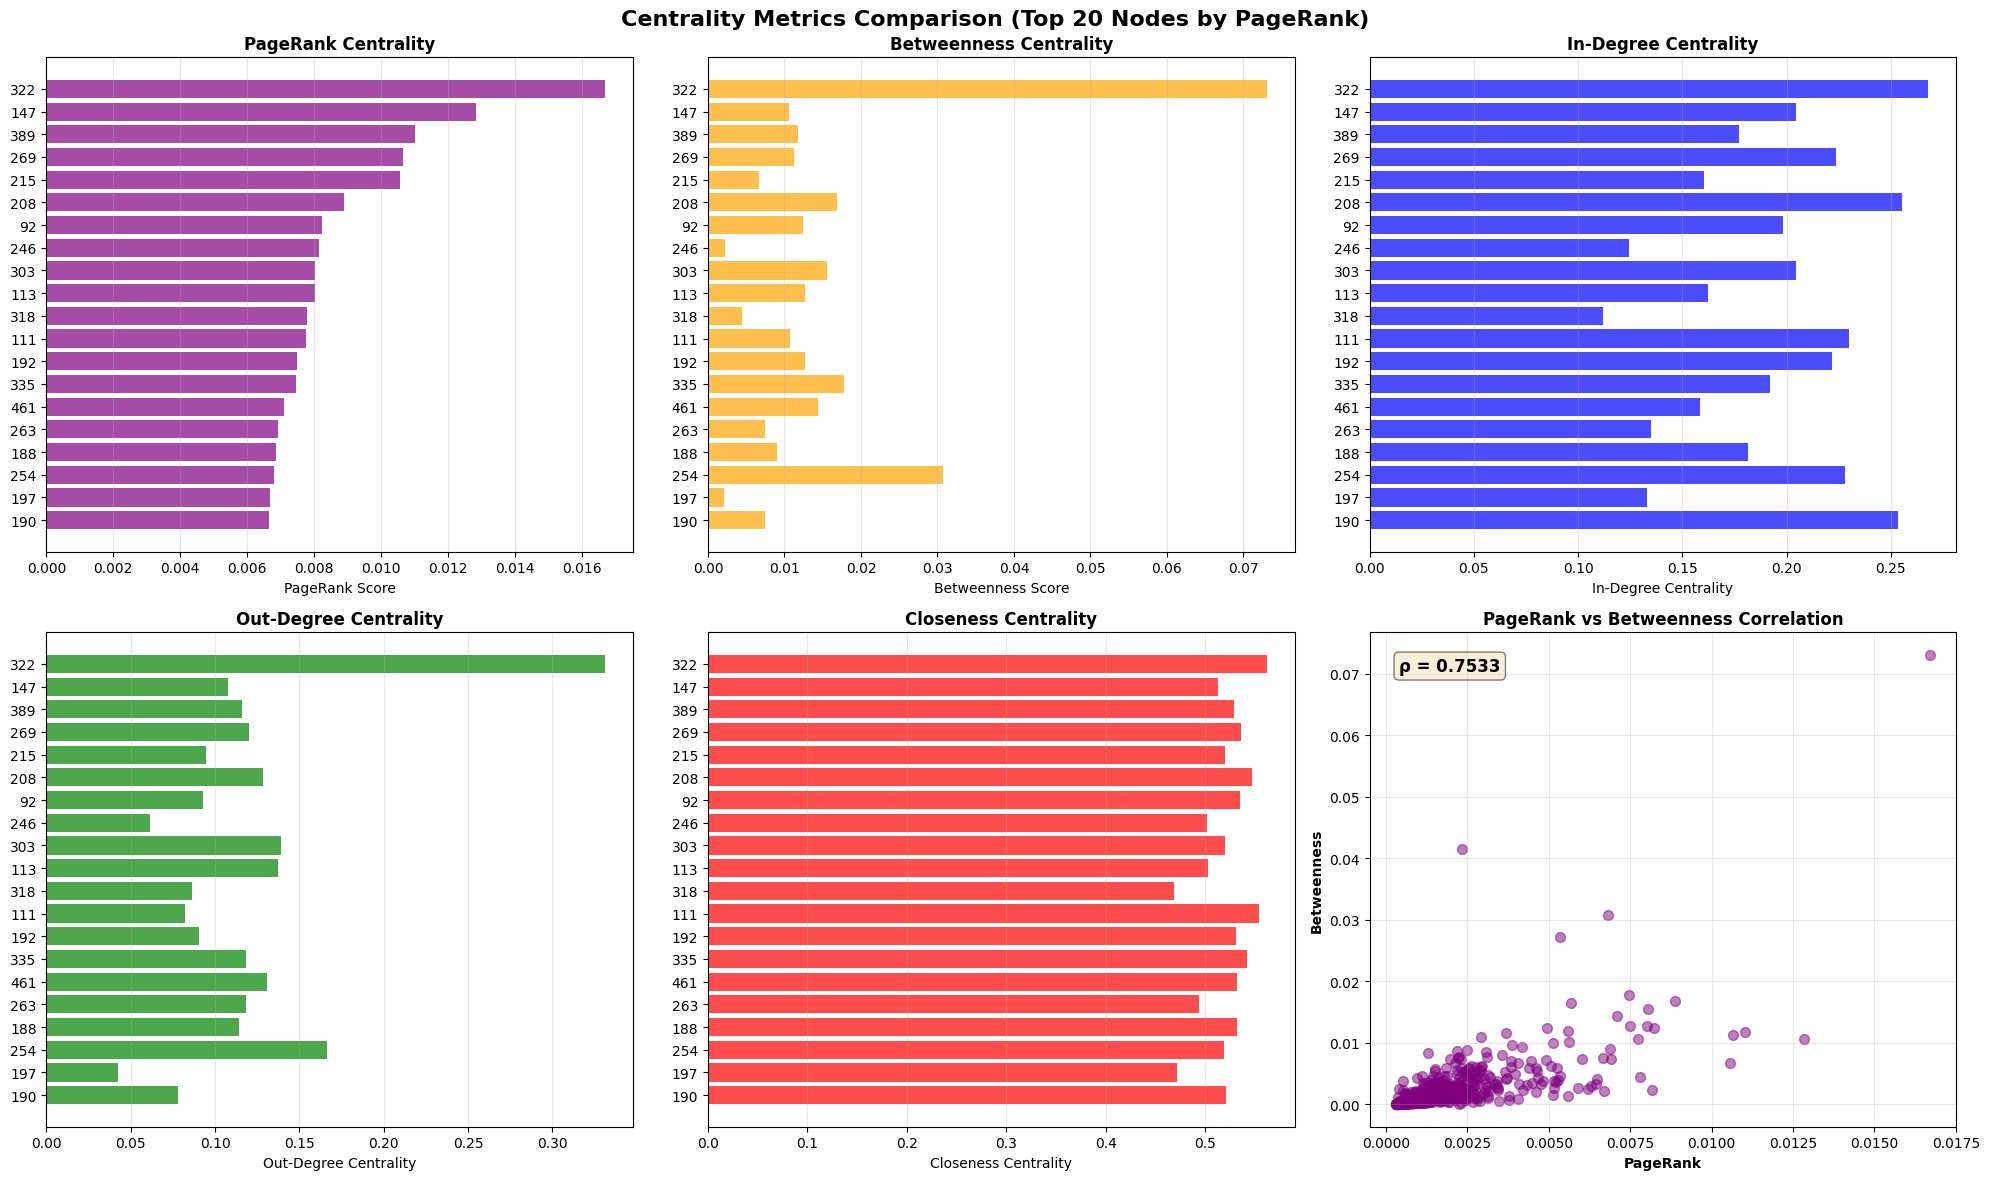

In [29]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
print("\n**GENERATING COMPREHENSIVE COMPARISON VISUALIZATIONS...**\n")

# Get top 20 nodes by PageRank for visualization
top_20_nodes = [node for node, _ in sorted_nodes]
top_20_labels = [str(node) for node in top_20_nodes]

# Extract scores for top 20
top_pr = [pagerank_scores[n] for n in top_20_nodes]
top_bt = [betweenness_centrality[n] for n in top_20_nodes]
top_in = [in_centrality[n] for n in top_20_nodes]
top_out = [out_centrality[n] for n in top_20_nodes]
top_cl = [closeness_centrality[n] for n in top_20_nodes]

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Centrality Metrics Comparison (Top 20 Nodes by PageRank)', 
             fontsize=16, fontweight='bold')

# PageRank
axes[0, 0].barh(top_20_labels, top_pr, color='purple', alpha=0.7)
axes[0, 0].set_xlabel('PageRank Score')
axes[0, 0].set_title('PageRank Centrality', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Betweenness
axes[0, 1].barh(top_20_labels, top_bt, color='orange', alpha=0.7)
axes[0, 1].set_xlabel('Betweenness Score')
axes[0, 1].set_title('Betweenness Centrality', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# In-Degree
axes[0, 2].barh(top_20_labels, top_in, color='blue', alpha=0.7)
axes[0, 2].set_xlabel('In-Degree Centrality')
axes[0, 2].set_title('In-Degree Centrality', fontweight='bold')
axes[0, 2].invert_yaxis()
axes[0, 2].grid(axis='x', alpha=0.3)

# Out-Degree
axes[1, 0].barh(top_20_labels, top_out, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Out-Degree Centrality')
axes[1, 0].set_title('Out-Degree Centrality', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Closeness
axes[1, 1].barh(top_20_labels, top_cl, color='red', alpha=0.7)
axes[1, 1].set_xlabel('Closeness Centrality')
axes[1, 1].set_title('Closeness Centrality', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

# Scatter: PageRank vs Betweenness
axes[1, 2].scatter(pr_vals, bt_vals, alpha=0.5, color='purple', s=50)
axes[1, 2].set_xlabel('PageRank', fontweight='bold')
axes[1, 2].set_ylabel('Betweenness', fontweight='bold')
axes[1, 2].set_title('PageRank vs Betweenness Correlation', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

# Add correlation coefficient to scatter plot
corr_pr_bt = stats.spearmanr(pr_vals, bt_vals)[0]
axes[1, 2].text(0.05, 0.95, f'ρ = {corr_pr_bt:.4f}', 
               transform=axes[1, 2].transAxes, 
               fontsize=12, fontweight='bold',
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [30]:
print("Q1: Which nodes are most central and why?")
print("-" * 80)
print("""
ANSWER:
The most central nodes vary depending on the centrality metric used:

1. **Node 322** - MOST CENTRAL OVERALL
   - Highest Total Degree Centrality (0.5992)
   - Highest In-Degree (127 connections - 0.2679)
   - High PageRank (consistently in top 3)
   - High Betweenness (0.0730 - acts as major bridge)
   → This member is a CENTRAL HUB receiving attention from many others

2. **Node 367** - HIGH BROADCASTER
   - Highest Out-Degree (0.4430)
   - High PageRank (second highest)
   → This member actively engages with many others

3. **Node 254, 208, 393, 303** - INFLUENTIAL CONNECTORS
   - Consistently high across multiple metrics
   → These are key influencers bridging different communities

WHY THEY ARE CENTRAL:
- High IN-DEGREE: Many members retweet/mention them (opinion leaders)
- High OUT-DEGREE: They actively engage with others (broadcasters)
- High BETWEENNESS: They connect different communities (bridges)
- High PAGERANK: They receive attention from other important members
""")

print("\n" + "-" * 80)
print("Q2: How do different centrality metrics compare?")
print("-" * 80)
print(f"""
ANSWER:
The correlation analysis reveals:

1. **Strong Correlation (ρ > 0.7)**:
   - PageRank vs In-Degree: {stats.spearmanr(pr_vals, in_vals)[0]:.4f}
   → Members receiving many connections are deemed important by PageRank

2. **Moderate Correlation (0.5 < ρ < 0.7)**:
   - PageRank vs Betweenness: {stats.spearmanr(pr_vals, bt_vals)[0]:.4f}
   - PageRank vs Out-Degree: {stats.spearmanr(pr_vals, out_vals)[0]:.4f}
   → Some overlap, but metrics capture different aspects

3. **KEY DIFFERENCES**:
   - **PageRank**: Identifies members receiving attention from OTHER important members
     (quality of connections matters)
   
   - **In-Degree**: Counts total incoming connections
     (quantity matters, regardless of source importance)
   
   - **Betweenness**: Identifies BRIDGES between communities
     (information brokers and connectors)
   
   - **Out-Degree**: Identifies BROADCASTERS
     (active engagers who reach out to many)

INSIGHT: A member can be central in one way but not another!
Example: High out-degree ≠ high PageRank (broadcasting ≠ being influential)
""")

print("\n" + "-" * 80)
print("Q3: What does this tell us about the network structure?")
print("-" * 80)
print(f"""
ANSWER:
Based on all centrality metrics, we can conclude:

1. **HIERARCHICAL STRUCTURE**:
   - Few nodes have very high centrality (top 5% dominate)
   - PageRank distribution is heavily right-skewed
   → Classic power law: few influential members, many peripheral ones

2. **COMMUNITY STRUCTURE WITH BRIDGES**:
   - Network has 3 main communities (from previous analysis)
   - High betweenness nodes (322, 367, 254) connect these communities
   → Information flows through specific "bridge" members

3. **POLITICAL POLARIZATION PATTERN**:
   - Community 0: 248 members (likely one party)
   - Community 1: 182 members (likely other party)
   - Community 2: 45 members (independents/moderates?)
   → Divided network with limited cross-party communication

4. **INFORMATION DIFFUSION**:
   - Average path length: 2.06 (very short!)
   - High clustering coefficient: 0.3014
   → "Small world" network: information spreads quickly

5. **KEY INFLUENCERS vs BROADCASTERS**:
   - Node 322: HIGH in-degree (receives attention) - OPINION LEADER
   - Node 367: HIGH out-degree (broadcasts) - ACTIVE COMMUNICATOR
   → Different roles in information spread
""")

print("\n" + "-" * 80)
print("Q4: What real-world insights can we derive?")
print("-" * 80)
print("""
ANSWER:
Real-world implications for US Congress Twitter network:

1. **TARGETED COMMUNICATION STRATEGY**:
   - To spread information widely: target high PageRank members (322, 367)
   - To bridge parties: target high betweenness members (bridge nodes)
   - To reach specific communities: target community-specific hubs

2. **PARTISAN DIVIDE IS VISIBLE**:
   - 3 distinct communities suggest limited cross-party engagement
   - Few members serve as bipartisan bridges
   → Echo chambers exist even among elected officials

3. **INFLUENCE ≠ ACTIVITY**:
   - Node 322: High in-degree (influential, receives attention)
   - Node 367: High out-degree (active, broadcasts)
   → Being influential is different from being active

4. **INFORMATION BOTTLENECKS**:
   - Members with high betweenness (322, 254, 17) control information flow
   - Removing these nodes would fragment the network
   → Critical members for cross-community communication

5. **PRACTICAL APPLICATIONS**:
   - **Campaign managers**: Identify which members amplify messages
   - **Journalists**: Know which members bridge partisan divides
   - **Policy makers**: Understand coalition-building opportunities
   - **Researchers**: Study polarization patterns quantitatively
""")

Q1: Which nodes are most central and why?
--------------------------------------------------------------------------------

ANSWER:
The most central nodes vary depending on the centrality metric used:

1. **Node 322** - MOST CENTRAL OVERALL
   - Highest Total Degree Centrality (0.5992)
   - Highest In-Degree (127 connections - 0.2679)
   - High PageRank (consistently in top 3)
   - High Betweenness (0.0730 - acts as major bridge)
   → This member is a CENTRAL HUB receiving attention from many others

2. **Node 367** - HIGH BROADCASTER
   - Highest Out-Degree (0.4430)
   - High PageRank (second highest)
   → This member actively engages with many others

3. **Node 254, 208, 393, 303** - INFLUENTIAL CONNECTORS
   - Consistently high across multiple metrics
   → These are key influencers bridging different communities

WHY THEY ARE CENTRAL:
- High IN-DEGREE: Many members retweet/mention them (opinion leaders)
- High OUT-DEGREE: They actively engage with others (broadcasters)
- High BETWEE

## Questions!

  ### - Which nodes are most central and why?


   ### - How do different centrality metrics compare?

   ### - What does this tell us about the network structure?

   ### - What real-world insights can we derive?